# `Taller 1` — Exploración y limpieza del dataset Diabetes

## Materia:

- Métodos Estadísticos para Analisis de Datos

## Docente

- **Nombre**: Julian Hoyos

## Estudiantes

- Jose David Losada Legarda 76261004
- Yaneth Viviana Pechene Cuchumbe 76261010
- Darlyn Kamila Mamian Uni 76261009

### Objetivo

Se aplica el mismo flujo del Titanic, ahora sobre un problema de regresión. La idea es dejar el dataset listo para modelar sin saltarse el paso de entenderlo. Se explora la estructura, se revisa la calidad de los datos, se detectan redundancias y se aplica una limpieza justificada.


### Sobre el dataset

Dataset clásico de Efron et al. (2004) con mediciones clínicas de 442 pacientes con diabetes. La variable objetivo `Y` mide la progresión de la enfermedad un año después de la visita inicial. Como `Y` es continua, el problema es de regresión.

| Columna | Tipo       | Descripción                               | Rango aproximado |
| ------- | ---------- | ----------------------------------------- | ---------------- |
| AGE     | numérico   | Edad del paciente en años                 | 19 a 79          |
| SEX     | categórico | Sexo codificado como 1 o 2                | dos categorías   |
| BMI     | numérico   | Índice de masa corporal                   | 18 a 42          |
| BP      | numérico   | Presión arterial media                    | 62 a 133         |
| S1      | numérico   | Colesterol total (tc)                     | 97 a 301         |
| S2      | numérico   | Lipoproteínas LDL                         | 41 a 242         |
| S3      | numérico   | Lipoproteínas HDL                         | 22 a 99          |
| S4      | numérico   | Cociente colesterol total sobre HDL       | 2 a 9            |
| S5      | numérico   | log de triglicéridos séricos              | 3.26 a 6.11      |
| S6      | numérico   | Glucosa en sangre                         | 58 a 124         |
| **Y**   | numérico   | **Variable objetivo**, progresión a 1 año | 25 a 346         |


### Carga del dataset

Se carga desde la URL pública. Un detalle importante, el archivo usa tabulaciones como separador, no comas. Sin pasar `sep="\t"` a pandas, todo quedaría en una sola columna.

Fuente https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"
df = pd.read_csv(url, sep="\t")

df.head(10)


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.00,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.00,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.00,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.00,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.00,4.2905,80,135
5,23,1,22.6,89.0,139,64.8,61.0,2.00,4.1897,68,97
6,36,2,22.0,90.0,160,99.6,50.0,3.00,3.9512,82,138
7,66,2,26.2,114.0,255,185.0,56.0,4.55,4.2485,92,63
8,60,2,32.1,83.0,179,119.4,42.0,4.00,4.4773,94,110
9,29,1,30.0,85.0,180,93.4,43.0,4.00,5.3845,88,310


In [2]:
dimensiones = df.shape
print(dimensiones)


(442, 11)


### Exploración inicial

Primer vistazo. Interesa saber qué variables hay, qué tipo asignó pandas a cada una y si hay valores faltantes.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


In [4]:
df.describe().round(2)


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,48.52,1.47,26.38,94.65,189.14,115.44,49.79,4.07,4.64,91.26,152.13
std,13.11,0.50,4.42,13.83,34.61,30.41,12.93,1.29,0.52,11.50,77.09
min,19.00,1.00,18.00,62.00,97.00,41.60,22.00,2.00,3.26,58.00,25.00
25%,38.25,1.00,23.20,84.00,164.25,96.05,40.25,3.00,4.28,83.25,87.00
50%,50.00,1.00,25.70,93.00,186.00,113.00,48.00,4.00,4.62,91.00,140.50
75%,59.00,2.00,29.28,105.00,209.75,134.50,57.75,5.00,5.00,98.00,211.50
max,79.00,2.00,42.20,133.00,301.00,242.40,99.00,9.09,6.11,124.00,346.00


`SEX` aparece como `int64` pero solo toma dos valores, es categórica. Se corrige en el bloque de limpieza.

También se observan escalas muy distintas entre variables. `S5` ronda 4, `Y` ronda 150 y `S1` supera 200. No es un problema ahora, pero importa si después se usa un modelo sensible a la escala.


### Valores perdidos

Mismo chequeo que en Titanic, ¿hay nulos por tratar?


In [5]:
df.isnull().sum()


AGE    0
SEX    0
BMI    0
BP     0
S1     0
S2     0
S3     0
S4     0
S5     0
S6     0
Y      0
dtype: int64

In [6]:
print(f"Filas duplicadas: {df.duplicated().sum()}")


Filas duplicadas: 0


Cero nulos y cero duplicados. Es la excepción más que la regla, en Titanic había 688 nulos solo en `deck`. Pero un dataset sin nulos no es un dataset listo. Falta revisar tipos, outliers y posibles redundancias entre columnas.


### Distribución del target `Y`

En regresión, el primer paso es mirar la distribución del target. Un sesgo fuerte o valores imposibles aparecen aquí, antes de invertir tiempo en los predictores.


/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_94199/3915472954.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(


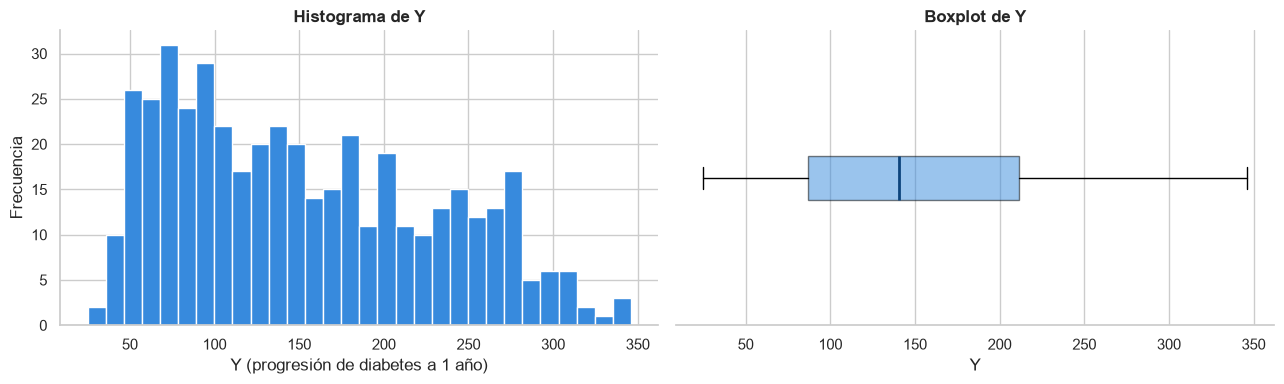

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["Y"], bins=30, color="#378ADD", edgecolor="white")
axes[0].set_title("Histograma de Y", fontweight="bold")
axes[0].set_xlabel("Y (progresión de diabetes a 1 año)")
axes[0].set_ylabel("Frecuencia")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].boxplot(
    df["Y"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#378ADD", alpha=0.5),
    medianprops=dict(color="#0C447C", linewidth=2),
)
axes[1].set_title("Boxplot de Y", fontweight="bold")
axes[1].set_xlabel("Y")
axes[1].set_yticks([])
axes[1].spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()


`Y` es asimétrica con cola a la derecha. Mediana cerca de 140 y casos cercanos a 350. El IQR no marca outliers en el target.

Una cola tan larga puede justificar más adelante transformar `Y` con logaritmo o usar métricas robustas como el error absoluto mediano en lugar del cuadrático medio.


### Distribución de los predictores

Mismo ejercicio para cada predictor. Además de la forma, interesa detectar escalas raras o concentraciones inusuales.


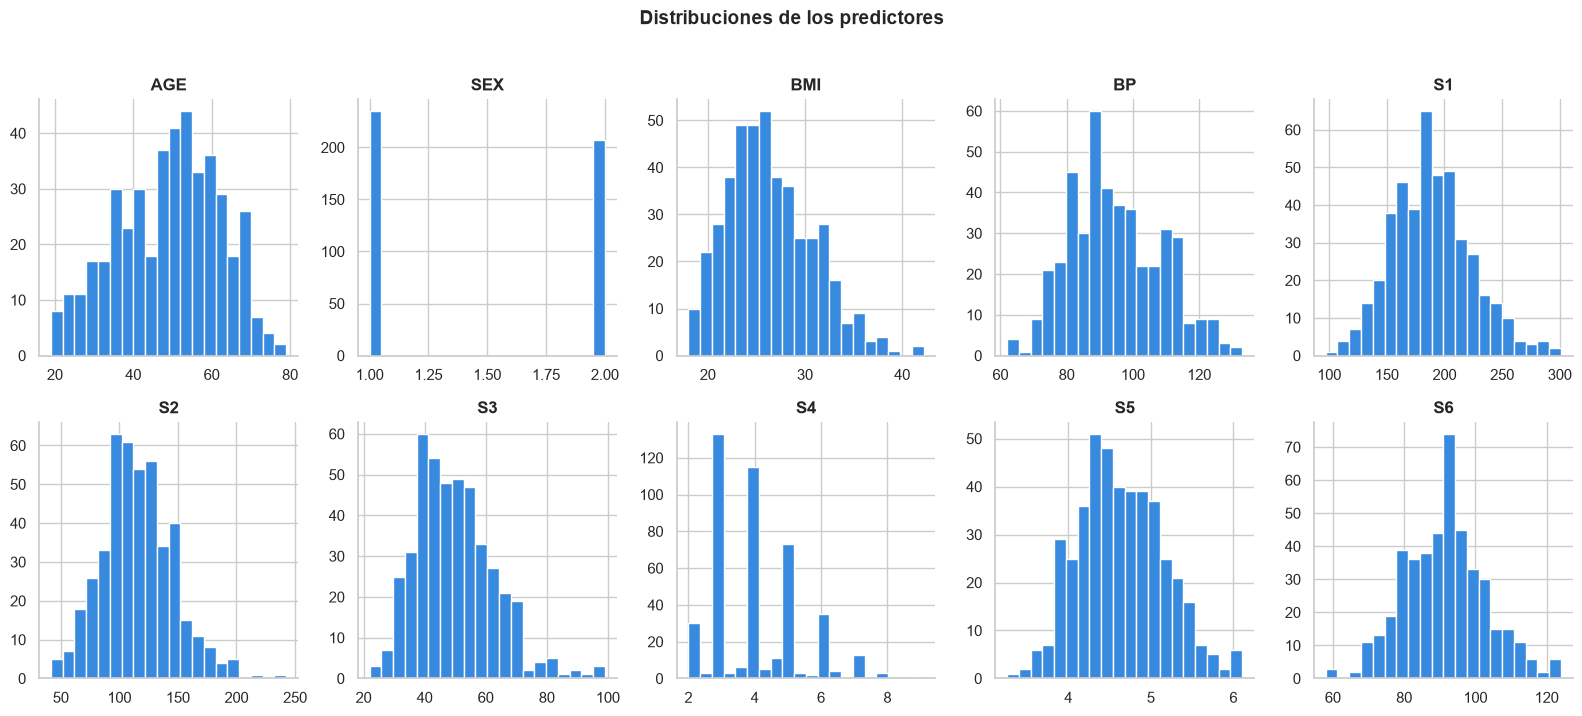

In [8]:
predictores = [c for c in df.columns if c != "Y"]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for ax, col in zip(axes, predictores):
    ax.hist(df[col], bins=20, color="#378ADD", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribuciones de los predictores", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


`SEX` se ve como dos barras gigantes porque solo tiene dos valores, confirma que es categórica. `AGE`, `BMI` y `BP` son bastante simétricas. Las `S1` a `S6` se comportan razonable, sin distribuciones bimodales ni picos sospechosos.


### Valores atípicos

Se aplica el criterio IQR igual que en Titanic. Todo valor fuera del rango `Q1 menos 1.5 IQR` o `Q3 mas 1.5 IQR` queda marcado como potencial atípico.

Una aclaración importante. Son mediciones clínicas reales, un colesterol alto no es un error de tipeo sino información médica. Los outliers se reportan pero no se eliminan.


Resumen de variables numéricas (método IQR):
Variable         Q1       Q3      IQR   Lim. inf   Lim. sup   Outliers
----------------------------------------------------------------
AGE           38.25    59.00    20.75       7.12      90.12          0
BMI           23.20    29.27     6.07      14.09      38.39          3
BP            84.00   105.00    21.00      52.50     136.50          0
S1           164.25   209.75    45.50      96.00     278.00          8
S2            96.05   134.50    38.45      38.37     192.18          7
S3            40.25    57.75    17.50      14.00      84.00          7
S4             3.00     5.00     2.00       0.00       8.00          2
S5             4.28     5.00     0.72       3.20       6.08          4
S6            83.25    98.00    14.75      61.12     120.12          9


/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_94199/1942389868.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_94199/1942389868.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_94199/1942389868.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_94199/1942389868.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horiz

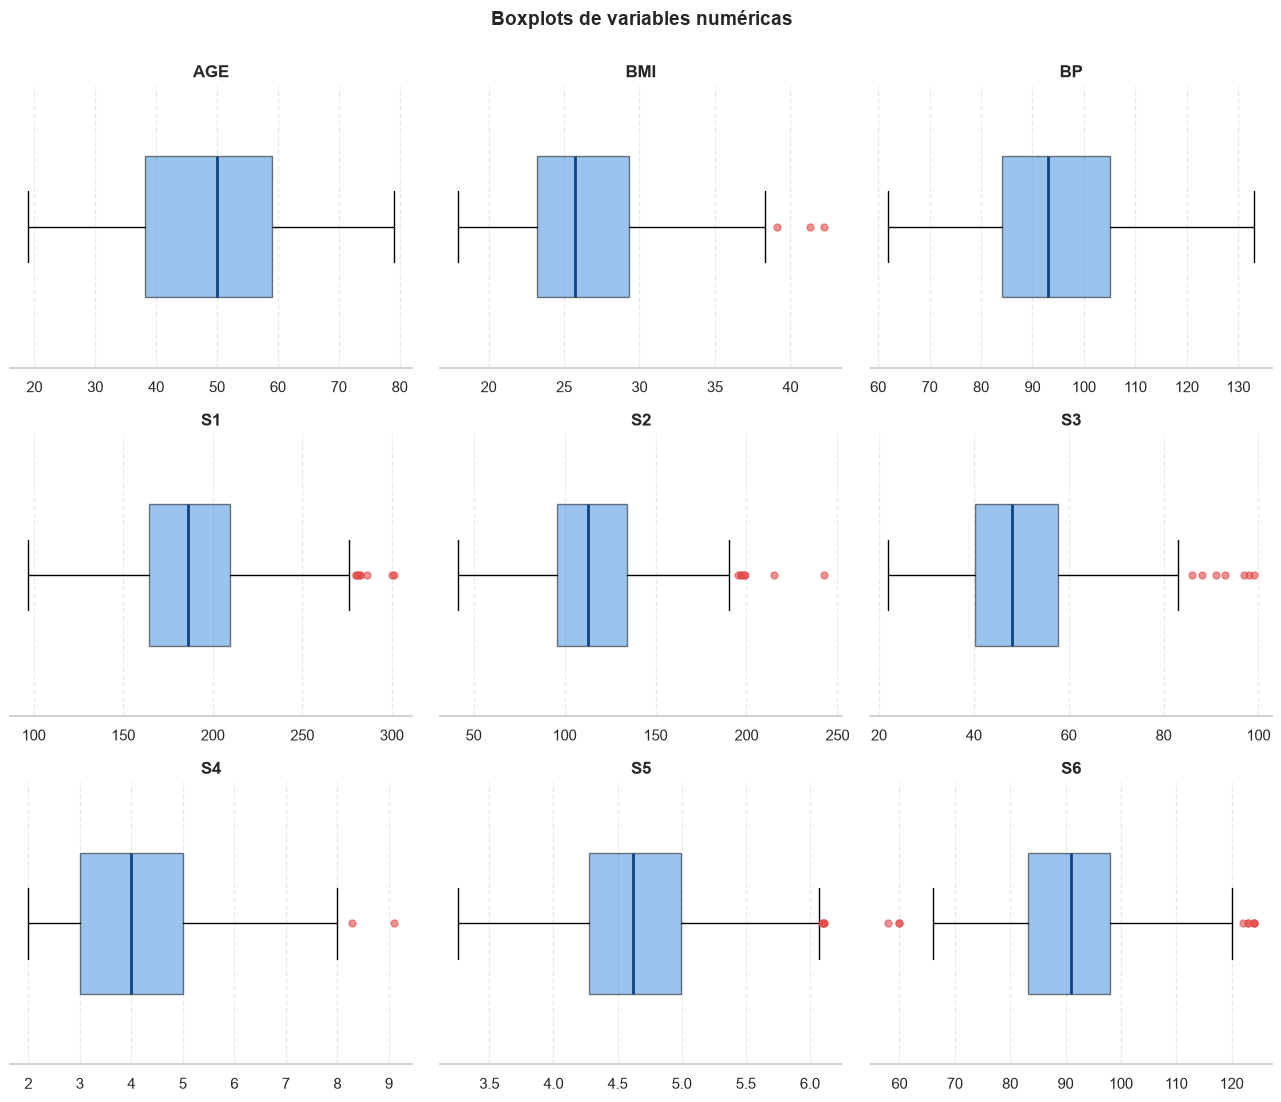

In [9]:
num_vars = ["AGE", "BMI", "BP", "S1", "S2", "S3", "S4", "S5", "S6"]

print("Resumen de variables numéricas (método IQR):")
print(
    f"{'Variable':<10} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lim. inf':>10} {'Lim. sup':>10} {'Outliers':>10}"
)
print("-" * 64)
for var in num_vars:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((df[var] < lim_inf) | (df[var] > lim_sup)).sum()
    print(
        f"{var:<10} {q1:>8.2f} {q3:>8.2f} {iqr:>8.2f} {lim_inf:>10.2f} {lim_sup:>10.2f} {n_out:>10}"
    )

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]
    bp = ax.boxplot(
        df[var],
        vert=False,
        patch_artist=True,
        widths=0.5,
        flierprops=dict(
            marker="o",
            markerfacecolor="#E24B4A",
            markeredgecolor="#E24B4A",
            markersize=5,
            alpha=0.6,
        ),
    )
    bp["boxes"][0].set_facecolor("#378ADD")
    bp["boxes"][0].set_alpha(0.5)
    bp["medians"][0].set_color("#0C447C")
    bp["medians"][0].set_linewidth(2)
    ax.set_title(var, fontweight="bold")
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("Boxplots de variables numéricas", fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()


Hay outliers en `BMI`, `S1`, `S2`, `S3`, `S5` y `S6`. En total entre 30 y 40 sobre 442 registros, una proporción baja. Se conservan por ser datos reales. Si un modelo posterior sufre por ellos, la decisión se puede revisar.


### Multicolinealidad entre predictores

Aquí está la parte más interesante. Cuando dos variables miden casi lo mismo, no aportan información nueva y complican los coeficientes del modelo. Es el mismo problema observado en Titanic con `who`, `adult_male` y `alone`.

Se calcula la matriz de correlación entre predictores y se grafica como heatmap.


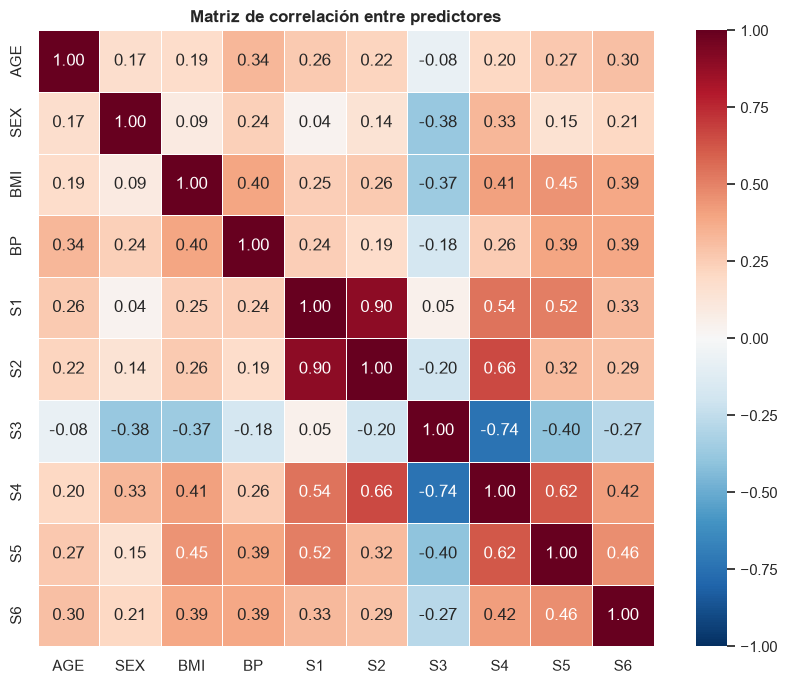

In [10]:
corr_pred = df[predictores].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_pred,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de correlación entre predictores", fontweight="bold")
plt.tight_layout()
plt.show()


Tres patrones llaman la atención.

`S1` y `S2` correlacionan `0.90`. Tiene sentido médico, `S1` es colesterol total y `S2` es LDL, una fracción mayoritaria del total. En la práctica, ambas variables dicen casi lo mismo.

`S4` muestra correlaciones altas con varias columnas. Vale `0.54` con `S1`, `0.66` con `S2` y `0.74` negativa con `S3`. La razón es que `S4` es el cociente entre colesterol total y HDL, depende matemáticamente de `S1` y `S3`.

El resto mantiene correlaciones moderadas o bajas, que es lo deseable.


### Confirmando que `S4` es una variable derivada

Para confirmarlo, se compara `S4` con el cociente calculado a mano `S1 / S3`. Si la correlación es muy alta, queda demostrado que `S4` no aporta información nueva.


In [11]:
s4_calculado = df["S1"] / df["S3"]
corr_s4 = df["S4"].corr(s4_calculado)
print(f"Correlación entre S4 y (S1 / S3): {corr_s4:.4f}")

df[["S1", "S3", "S4"]].assign(S4_calculado=s4_calculado.round(2)).head(8)


Correlación entre S4 y (S1 / S3): 0.9790


,S1,S3,S4,S4_calculado
0,157,38.0,4.00,4.13
1,183,70.0,3.00,2.61
2,156,41.0,4.00,3.80
3,198,40.0,5.00,4.95
4,192,52.0,4.00,3.69
5,139,61.0,2.00,2.28
6,160,50.0,3.00,3.20
7,255,56.0,4.55,4.55


Correlación de `0.98`, prácticamente uno. `S4` es una variable derivada. La decisión sobre qué hacer con ella va en el bloque de limpieza.


### Decisiones de limpieza

**Tipar `SEX` como categórica.** Solo tiene dos valores, no tiene sentido tratarla como numérica. Que `SEX = 2` valga el doble que `SEX = 1` no significa nada.

**Eliminar `S2`.** Su correlación de `0.90` con `S1` indica redundancia. Se conserva `S1` por ser más interpretable (colesterol total).

**Eliminar `S4`.** Es el cociente `S1 / S3`, una variable derivada. Mantenerla introduce dependencia matemática exacta entre columnas, lo que vuelve inestables los coeficientes en modelos lineales.

**Conservar los outliers.** Son datos clínicos reales, no errores. Eliminar pacientes con colesterol alto en un estudio sobre progresión de diabetes sería contraproducente.


### Aplicar la limpieza


In [12]:
df["SEX"] = df["SEX"].astype("category")


In [13]:
df = df.drop(columns=["S2", "S4"])


### Revisión final

Chequeo final. Las columnas eliminadas no deben aparecer, `SEX` debe figurar como `category` y deben mantenerse las 442 filas originales.


In [14]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   AGE     442 non-null    int64   
 1   SEX     442 non-null    category
 2   BMI     442 non-null    float64 
 3   BP      442 non-null    float64 
 4   S1      442 non-null    int64   
 5   S3      442 non-null    float64 
 6   S5      442 non-null    float64 
 7   S6      442 non-null    int64   
 8   Y       442 non-null    int64   
dtypes: category(1), float64(4), int64(4)
memory usage: 28.2 KB


In [15]:
df.head()


,AGE,SEX,BMI,BP,S1,S3,S5,S6,Y
0,59,2,32.1,101.0,157,38.0,4.8598,87,151
1,48,1,21.6,87.0,183,70.0,3.8918,69,75
2,72,2,30.5,93.0,156,41.0,4.6728,85,141
3,24,1,25.3,84.0,198,40.0,4.8903,89,206
4,50,1,23.0,101.0,192,52.0,4.2905,80,135


In [16]:
df.isnull().sum()


AGE    0
SEX    0
BMI    0
BP     0
S1     0
S3     0
S5     0
S6     0
Y      0
dtype: int64

### Conclusión

El desafío fue distinto al de Titanic. Aquí los datos llegaron completos pero con columnas redundantes, y solo se detectaron mirando la matriz de correlación y entendiendo el origen clínico de cada variable.

La moraleja, un dataset sin nulos no es un dataset listo. La limpieza también incluye revisar tipos, eliminar redundancias y decidir qué hacer con los outliers según el dominio.

Resultado, 442 filas y 9 columnas, `SEX` correctamente tipada, dos columnas redundantes eliminadas, ningún registro descartado.


### Nota, auditoría posterior con el análisis inferencial

Estas decisiones de limpieza se revisaron más adelante con el análisis estadístico inferencial, cruzándolas contra la variable objetivo `Y` que en esta etapa todavía no se había considerado.

La eliminación de `S2` quedó validada. Se conservó `S1`, que predice la progresión mejor que `S2`, correlación 0.21 frente a 0.17.

La eliminación de `S4` quedó marcada como discutible. `S4` correlacionaba 0.43 con la progresión, más que la mayoría de las variables conservadas. Se descartó por ser derivada, lo cual es correcto para evitar dependencia matemática en modelos lineales, pero implicó perder un predictor fuerte. El detalle queda documentado en el notebook de análisis inferencial.

Conservar los outliers también quedó validado, el diagnóstico de influencia mostró que no distorsionan el modelo.


### Exportar el dataset limpio

Se guarda en `data/processed/` para que otros notebooks lo usen sin repetir todo el proceso de limpieza.


In [17]:
from pathlib import Path

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

salida = PROCESSED_DIR / "diabetes_limpio.csv"
df.to_csv(salida, index=False)

print(f"Guardado en: {salida}")
print(f"Shape final: {df.shape}")


Guardado en: /Users/noovou/dev/fup/estadistica/data/processed/diabetes_limpio.csv
Shape final: (442, 9)
